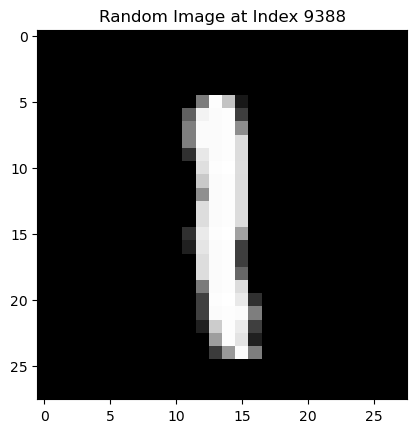

In [1]:
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST CSV
file_path = "mnist_test.csv"  # Replace with your actual file path
mnist_data = pd.read_csv(file_path)

# Choose a random row index (skip the first column, which is the label
random_index = np.random.randint(0, len(mnist_data))  # Random index from 0 to len(dataset)-1

# Extract the selected row and reshape it to 28x28
random_image = mnist_data.iloc[random_index, 1:].values.reshape(28, 28).astype(np.uint8)  # Skip label column

# Convert to Pillow Image
img = Image.fromarray(random_image)

# Display the Random Image
plt.imshow(img, cmap="gray")
plt.title(f"Random Image at Index {random_index}")
plt.show()


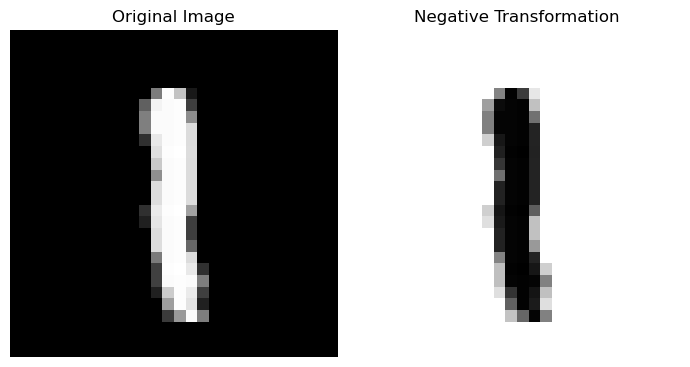

In [2]:
# Negative Transformation
img_negative = Image.fromarray(255 - random_image)

# Create Subplots for Side-by-Side Display
fig, axes = plt.subplots(1, 2, figsize=(7, 7))  # 1 row, 2 columns
axes[0].imshow(random_image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")  # Turn off axis for better visualization

axes[1].imshow(img_negative, cmap="gray")
axes[1].set_title("Negative Transformation")
axes[1].axis("off")  # Turn off axis

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

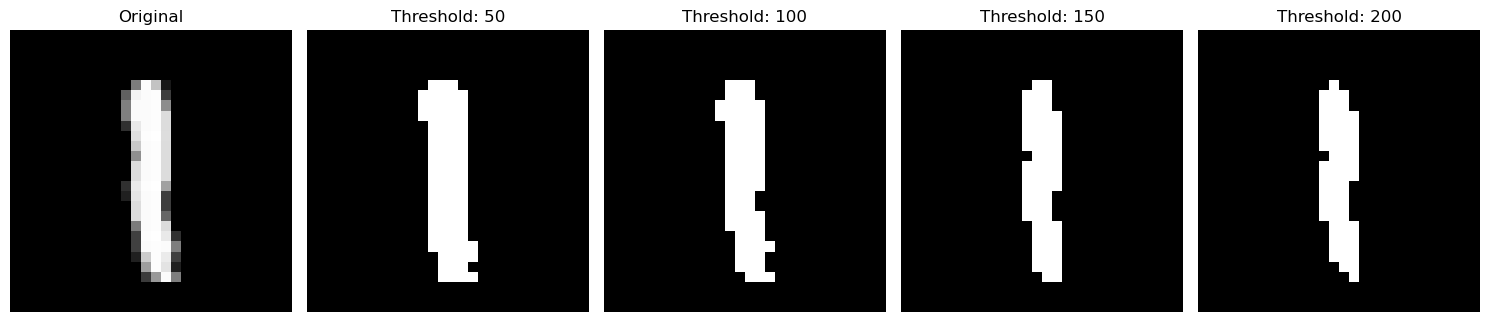

In [3]:
#THRESHOLDING
thresholds = [50, 100, 150, 200]

# Create Subplots
fig, axes = plt.subplots(1, len(thresholds) + 1, figsize=(15, 5))  # 1 row, len(thresholds)+1 columns

# Display Original Image
axes[0].imshow(random_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

# Display Thresholded Images
for i, t in enumerate(thresholds):
    thresholded = (random_image > t) * 255  # Apply thresholding
    axes[i + 1].imshow(thresholded, cmap="gray")
    axes[i + 1].set_title(f"Threshold: {t}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

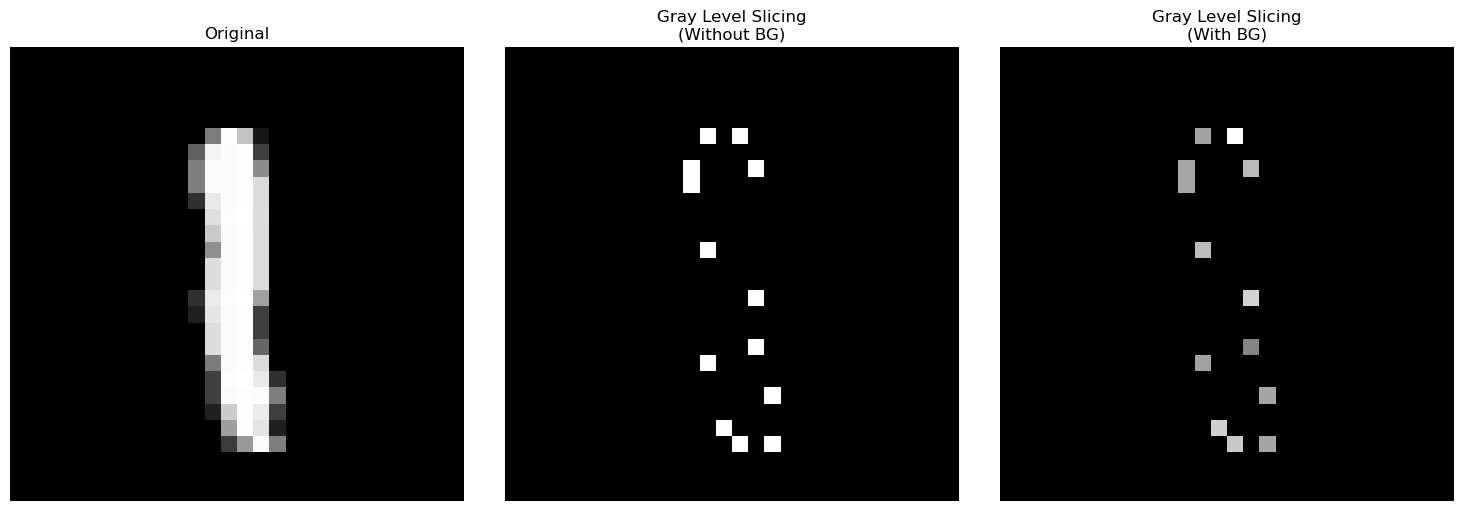

In [4]:
# Gray Level Slicing Parameters
low, high = 100, 200  # Range for gray level slicing

# Create Subplots for Gray Level Slicing
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

# Display Original Image
axes[0].imshow(random_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

# Gray Level Slicing without Background
sliced_without_bg = random_image.copy()
for i in range(random_image.shape[0]):
    for j in range(random_image.shape[1]):
        if low <= random_image[i, j] <= high:
            sliced_without_bg[i, j] = 255  # Set to white
        else:
            sliced_without_bg[i, j] = 0  # Set to black
axes[1].imshow(sliced_without_bg, cmap="gray")
axes[1].set_title(f"Gray Level Slicing\n(Without BG)")
axes[1].axis("off")

# Gray Level Slicing with Background
sliced_with_bg = random_image.copy()
for i in range(random_image.shape[0]):
    for j in range(random_image.shape[1]):
        if not (low <= random_image[i, j] <= high):
            sliced_with_bg[i, j] = 0  # Set background pixels to black
axes[2].imshow(sliced_with_bg, cmap="gray")
axes[2].set_title(f"Gray Level Slicing\n(With BG)")
axes[2].axis("off")

plt.tight_layout()
plt.show()